<a href="https://colab.research.google.com/github/jeongujeong117-byte/deep_learning_study/blob/master/new_model_chat_bot/cifar10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, t_train), (x_test, t_test) = cifar10.load_data()

print(x_train.shape)
print(t_train.shape)

(50000, 32, 32, 3)
(50000, 1)


In [ ]:
import numpy as np

t_train = t_train.reshape(-1)
t_test = t_test.reshape(-1)

train_mask = (t_train == 3) | (t_train == 5)
test_mask = (t_test == 3) | (t_test == 5)

x_train_cd = x_train[train_mask]
t_train_cd = t_train[train_mask]

x_test_cd = x_test[test_mask]
t_test_cd = t_test[test_mask]

t_train_cd = np.where(t_train_cd == 3, 0, 1)
t_test_cd = np.where(t_test_cd == 3, 0, 1)

print(x_train_cd.shape)
print(t_train_cd.shape)

print(x_test_cd.shape)
print(t_test_cd.shape)

print(t_train_cd[:20])

(10000, 32, 32, 3)
(10000,)
(2000, 32, 32, 3)
(2000,)
[0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 0 1 1 0]


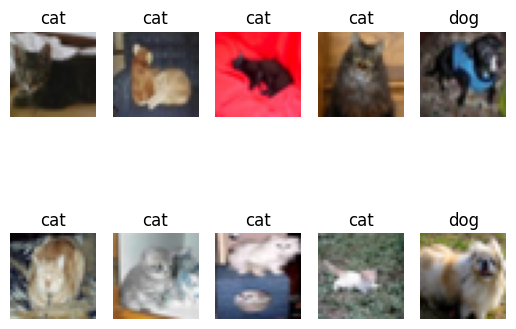

In [ ]:
import matplotlib.pyplot as plt

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_cd[i])
    plt.title("cat" if t_train_cd[i] == 0 else "dog")
    plt.axis("off")

plt.show()

In [ ]:
print(x_train_cd.dtype)
print(x_train_cd.min())
print(x_train_cd.max())

print(x_train_cd[0, 0, 0])

uint8
0
255
[125 125 116]


In [ ]:
x_train_cd = x_train_cd.astype(np.float32) / 255.0
x_test_cd = x_test_cd.astype(np.float32) / 255.0

In [ ]:
x_train_cd.astype(np.float32)

array([[[[0.49019608, 0.49019608, 0.45490196],
         [0.43137255, 0.39607844, 0.35686275],
         [0.4       , 0.3529412 , 0.3254902 ],
         ...,
         [0.7921569 , 0.8117647 , 0.8392157 ],
         [0.78431374, 0.8039216 , 0.83137256],
         [0.7921569 , 0.8156863 , 0.8392157 ]],

        [[0.5568628 , 0.57254905, 0.5568628 ],
         [0.57254905, 0.5647059 , 0.54509807],
         [0.6901961 , 0.6745098 , 0.6666667 ],
         ...,
         [0.7647059 , 0.7882353 , 0.8039216 ],
         [0.7764706 , 0.8039216 , 0.81960785],
         [0.8       , 0.827451  , 0.84313726]],

        [[0.7058824 , 0.7254902 , 0.7176471 ],
         [0.56078434, 0.57254905, 0.57254905],
         [0.6117647 , 0.6156863 , 0.6156863 ],
         ...,
         [0.47843137, 0.43529412, 0.44313726],
         [0.54509807, 0.5019608 , 0.5137255 ],
         [0.61960787, 0.5764706 , 0.5882353 ]],

        ...,

        [[0.40784314, 0.32156864, 0.16078432],
         [0.39607844, 0.3137255 , 0.15294118]

In [ ]:
print(x_train_cd.dtype)
print(x_train_cd.min())
print(x_train_cd.max())
print(x_train_cd[0, 0, 0])

float32
0.0
1.0
[0.49019608 0.49019608 0.45490196]


In [ ]:
x_train_cd = x_train_cd.transpose(0, 3, 1, 2)
x_test_cd = x_test_cd.transpose(0, 3, 1, 2)

In [ ]:
print(x_train_cd.shape)
print(x_test_cd.shape)

(10000, 3, 32, 32)
(2000, 3, 32, 32)


In [ ]:
np.random.seed(42)

indices = np.random.permutation(len(x_train_cd))

validation_num = int(len(x_train_cd) * 0.2)

val_idx = indices[:validation_num]
train_idx = indices[validation_num:]

x_val = x_train_cd[val_idx]
t_val = t_train_cd[val_idx]

x_train_final = x_train_cd[train_idx]
t_train_final = t_train_cd[train_idx]

print("train:", x_train_final.shape, t_train_final.shape)
print("validation:", x_val.shape, t_val.shape)
print("test:", x_test_cd.shape, t_test_cd.shape)

train: (8000, 3, 32, 32) (8000,)
validation: (2000, 3, 32, 32) (2000,)
test: (2000, 3, 32, 32) (2000,)


In [ ]:
from collections import OrderedDict

from common.layers import *
from common.gradient import numerical_gradient

ModuleNotFoundError: No module named 'common'

In [ ]:
def im2col(input_data, filter_h, filter_w, stride=1, pad=0):
    N, C, H, W = input_data.shape

    out_h = (H + 2 * pad - filter_h) // stride + 1
    out_w = (W + 2 * pad - filter_w) // stride + 1

    img = np.pad(
        input_data,
        [(0, 0), (0, 0), (pad, pad), (pad, pad)],
        mode='constant'
    )

    col = np.zeros(
        (N, C, filter_h, filter_w, out_h, out_w)
    )

    for y in range(filter_h):
        y_max = y + stride * out_h

        for x in range(filter_w):
            x_max = x + stride * out_w

            col[:, :, y, x, :, :] = \
                img[:, :, y:y_max:stride, x:x_max:stride]

    col = col.transpose(0, 4, 5, 1, 2, 3)

    col = col.reshape(
        N * out_h * out_w,
        -1
    )

    return col

In [ ]:
test_x = x_train_final[:2]

test_col = im2col(
    test_x,
    filter_h=3,
    filter_w=3,
    stride=1,
    pad=1
)

print("input:", test_x.shape)
print("im2col:", test_col.shape)

input: (2, 3, 32, 32)
im2col: (2048, 27)


In [ ]:
def col2im(col, input_shape, filter_h, filter_w, stride=1, pad=0):
    N, C, H, W = input_shape

    out_h = (H + 2 * pad - filter_h) // stride + 1
    out_w = (W + 2 * pad - filter_w) // stride + 1

    col = col.reshape(
        N,
        out_h,
        out_w,
        C,
        filter_h,
        filter_w
    )

    col = col.transpose(0, 3, 4, 5, 1, 2)

    img = np.zeros(
        (
            N,
            C,
            H + 2 * pad + stride - 1,
            W + 2 * pad + stride - 1
        )
    )

    for y in range(filter_h):
        y_max = y + stride * out_h

        for x in range(filter_w):
            x_max = x + stride * out_w

            img[:, :, y:y_max:stride, x:x_max:stride] += \
                col[:, :, y, x, :, :]

    return img[:, :, pad:H + pad, pad:W + pad]

In [ ]:
class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W
        self.b = b

        self.stride = stride
        self.pad = pad

        # backward 때 사용할 값
        self.x = None
        self.col = None
        self.col_W = None

        # gradient
        self.dW = None
        self.db = None

    def forward(self, x):
        FN, C, FH, FW = self.W.shape
        N, C, H, W = x.shape

        out_h = (H + 2 * self.pad - FH) // self.stride + 1
        out_w = (W + 2 * self.pad - FW) // self.stride + 1

        col = im2col(
            x,
            FH,
            FW,
            self.stride,
            self.pad
        )

        col_W = self.W.reshape(FN, -1).T

        out = np.dot(col, col_W) + self.b

        out = out.reshape(
            N,
            out_h,
            out_w,
            FN
        )

        out = out.transpose(0, 3, 1, 2)

        self.x = x
        self.col = col
        self.col_W = col_W

        return out

    def backward(self, dout):
        FN, C, FH, FW = self.W.shape

        dout = dout.transpose(0, 2, 3, 1)
        dout = dout.reshape(-1, FN)

        self.db = np.sum(dout, axis=0)

        self.dW = np.dot(
            self.col.T,
            dout
        )

        self.dW = self.dW.transpose(1, 0)
        self.dW = self.dW.reshape(
            FN,
            C,
            FH,
            FW
        )

        dcol = np.dot(
            dout,
            self.col_W.T
        )

        dx = col2im(
            dcol,
            self.x.shape,
            FH,
            FW,
            self.stride,
            self.pad
        )

        return dx

In [ ]:
W_test = np.random.randn(
    16, 3, 3, 3
)

b_test = np.zeros(16)

conv_test = Convolution(
    W_test,
    b_test,
    stride=1,
    pad=1
)

x_test_sample = x_train_final[:2]

out = conv_test.forward(x_test_sample)

print("input :", x_test_sample.shape)
print("W     :", W_test.shape)
print("output:", out.shape)

input : (2, 3, 32, 32)
W     : (16, 3, 3, 3)
output: (2, 16, 32, 32)


In [ ]:
class Relu:
    def __init__(self):
        self.mask = None

    def forward(self, x):
        self.mask = (x <= 0)

        out = x.copy()
        out[self.mask] = 0

        return out

    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout

        return dx

In [ ]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=1, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad

        self.x = None
        self.arg_max = None

    def forward(self, x):
        N, C, H, W = x.shape

        out_h = (H - self.pool_h) // self.stride + 1
        out_w = (W - self.pool_w) // self.stride + 1

        # 1. Pooling 영역을 im2col로 펼치기
        col = im2col(
            x,
            self.pool_h,
            self.pool_w,
            self.stride,
            self.pad
        )

        # 2. 채널별 pooling 영역으로 재배치
        col = col.reshape(-1, self.pool_h * self.pool_w)

        # 3. 각 영역의 최댓값 위치 저장
        arg_max = np.argmax(col, axis=1)

        # 4. 각 영역의 최댓값 선택
        out = np.max(col, axis=1)

        # 5. 원래 CNN 출력 구조로 복원
        out = out.reshape(
            N,
            out_h,
            out_w,
            C
        )

        out = out.transpose(0, 3, 1, 2)

        self.x = x
        self.arg_max = arg_max

        return out

In [ ]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=1, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad

        self.x = None
        self.arg_max = None

    def forward(self, x):
        N, C, H, W = x.shape

        out_h = (H - self.pool_h) // self.stride + 1
        out_w = (W - self.pool_w) // self.stride + 1

        col = im2col(
            x,
            self.pool_h,
            self.pool_w,
            self.stride,
            self.pad
        )

        col = col.reshape(
            -1,
            self.pool_h * self.pool_w
        )

        arg_max = np.argmax(col, axis=1)

        out = np.max(col, axis=1)

        out = out.reshape(
            N,
            out_h,
            out_w,
            C
        )

        out = out.transpose(0, 3, 1, 2)

        self.x = x
        self.arg_max = arg_max

        return out

    def backward(self, dout):
        dout = dout.transpose(0, 2, 3, 1)

        pool_size = self.pool_h * self.pool_w

        dmax = np.zeros(
            (
                dout.size,
                pool_size
            )
        )

        dmax[
            np.arange(self.arg_max.size),
            self.arg_max.flatten()
        ] = dout.flatten()

        dmax = dmax.reshape(
            dout.shape + (pool_size,)
        )

        dcol = dmax.reshape(
            dmax.shape[0] *
            dmax.shape[1] *
            dmax.shape[2],
            -1
        )

        dx = col2im(
            dcol,
            self.x.shape,
            self.pool_h,
            self.pool_w,
            self.stride,
            self.pad
        )

        return dx

In [ ]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b

        self.x = None
        self.original_x_shape = None

        self.dW = None
        self.db = None

    def forward(self, x):
        # CNN의 4차원 데이터를 나중에 복원하기 위해 원래 모양 저장
        self.original_x_shape = x.shape

        # 한 이미지의 모든 특징을 일렬로 펼치기
        x = x.reshape(x.shape[0], -1)

        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)

        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        # forward에서 펼쳤던 것을 원래 CNN 모양으로 복원
        dx = dx.reshape(*self.original_x_shape)

        return dx

In [ ]:
class Affine:
    def __init__(self, W, b):
        self.W = W
        self.b = b

        self.x = None
        self.original_x_shape = None

        self.dW = None
        self.db = None

    def forward(self, x):
        self.original_x_shape = x.shape

        x = x.reshape(x.shape[0], -1)
        self.x = x

        out = np.dot(self.x, self.W) + self.b

        return out

    def backward(self, dout):
        dx = np.dot(dout, self.W.T)

        self.dW = np.dot(self.x.T, dout)
        self.db = np.sum(dout, axis=0)

        dx = dx.reshape(*self.original_x_shape)

        return dx

In [ ]:
def softmax(x):
    if x.ndim == 2:
        x = x - np.max(x, axis=1, keepdims=True)

        exp_x = np.exp(x)

        return exp_x / np.sum(
            exp_x,
            axis=1,
            keepdims=True
        )

    x = x - np.max(x)

    return np.exp(x) / np.sum(np.exp(x))


def cross_entropy_error(y, t):
    if y.ndim == 1:
        y = y.reshape(1, -1)
        t = t.reshape(1, -1)

    batch_size = y.shape[0]

    return -np.sum(
        np.log(
            y[np.arange(batch_size), t] + 1e-7
        )
    ) / batch_size

In [ ]:
class SoftmaxWithLoss:
    def __init__(self):
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t

        self.y = softmax(x)

        self.loss = cross_entropy_error(
            self.y,
            self.t
        )

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]

        dx = (
            self.y.copy()
        )

        dx[
            np.arange(batch_size),
            self.t
        ] -= 1

        dx = dx / batch_size

        return dx * dout

In [ ]:
class Adam:
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2

        self.iter = 0
        self.m = None
        self.v = None

    def update(self, params, grads):
        if self.m is None:
            self.m = {}
            self.v = {}

            for key, val in params.items():
                self.m[key] = np.zeros_like(val)
                self.v[key] = np.zeros_like(val)

        self.iter += 1

        lr_t = self.lr * np.sqrt(
            1.0 - self.beta2 ** self.iter
        ) / (1.0 - self.beta1 ** self.iter)

        for key in params.keys():
            self.m[key] += (
                1 - self.beta1
            ) * (grads[key] - self.m[key])

            self.v[key] += (
                1 - self.beta2
            ) * (grads[key] ** 2 - self.v[key])

            params[key] -= (
                lr_t
                * self.m[key]
                / (np.sqrt(self.v[key]) + 1e-7)
            )

In [ ]:
from collections import OrderedDict


class CatDogConvNet:
    def __init__(self):
        # 기존에 작성한 __init__ 내용
        # 그대로 유지
        ...

    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)
        return x

    def loss(self, x, t):
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        return np.mean(y == t)

    def gradient(self, x, t):
        # 1. forward
        self.loss(x, t)

        # 2. backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()

        for layer in layers:
            dout = layer.backward(dout)

        # 3. 각 가중치의 gradient 수집
        grads = {}

        grads['W1'] = self.layers['Conv1'].dW
        grads['b1'] = self.layers['Conv1'].db

        grads['W2'] = self.layers['Conv2'].dW
        grads['b2'] = self.layers['Conv2'].db

        grads['W3'] = self.layers['Affine1'].dW
        grads['b3'] = self.layers['Affine1'].db

        grads['W4'] = self.layers['Affine2'].dW
        grads['b4'] = self.layers['Affine2'].db

        return grads

In [ ]:
def predict(self, x):
    for layer in self.layers.values():
        x = layer.forward(x)

    return x

In [ ]:
def loss(self, x, t):
    y = self.predict(x)
    return self.last_layer.forward(y, t)


def accuracy(self, x, t):
    y = self.predict(x)
    y = np.argmax(y, axis=1)

    return np.mean(y == t)


def gradient(self, x, t):
    # 먼저 forward
    self.loss(x, t)

    # 그 다음 backward
    dout = 1
    dout = self.last_layer.backward(dout)

    layers = list(self.layers.values())
    layers.reverse()

    for layer in layers:
        dout = layer.backward(dout)

    # 각 layer가 계산한 gradient 수집
    grads = {}

    grads['W1'] = self.layers['Conv1'].dW
    grads['b1'] = self.layers['Conv1'].db

    grads['W2'] = self.layers['Conv2'].dW
    grads['b2'] = self.layers['Conv2'].db

    grads['W3'] = self.layers['Affine1'].dW
    grads['b3'] = self.layers['Affine1'].db

    grads['W4'] = self.layers['Affine2'].dW
    grads['b4'] = self.layers['Affine2'].db

    return grads

In [ ]:
network = CatDogConvNet()
optimizer = Adam(lr=0.001)

batch_size = 50
train_size = 2000
epochs = 5

x_small = x_train_final[:train_size]
t_small = t_train_final[:train_size]

In [ ]:
for epoch in range(epochs):

    indices = np.random.permutation(train_size)

    for i in range(0, train_size, batch_size):

        batch_idx = indices[i:i + batch_size]

        x_batch = x_small[batch_idx]
        t_batch = t_small[batch_idx]

        # 1. gradient 계산
        grads = network.gradient(x_batch, t_batch)

        # 2. W, b 업데이트
        optimizer.update(network.params, grads)

    # 한 epoch이 끝나면 성적 확인
    loss = network.loss(x_small[:500], t_small[:500])
    acc = network.accuracy(x_val[:500], t_val[:500])

    print(
        f"epoch {epoch + 1} | "
        f"loss {loss:.4f} | "
        f"val acc {acc:.4f}"
    )

AttributeError: 'CatDogConvNet' object has no attribute 'layers'

In [ ]:
from collections import OrderedDict

class CatDogConvNet:
    def __init__(self):
        hidden_size = 100
        output_size = 2

        # =========================
        # 파라미터 생성
        # =========================
        self.params = {}

        self.params['W1'] = (
            np.sqrt(2.0 / (3 * 3 * 3))
            * np.random.randn(16, 3, 3, 3)
        )
        self.params['b1'] = np.zeros(16)

        self.params['W2'] = (
            np.sqrt(2.0 / (16 * 3 * 3))
            * np.random.randn(32, 16, 3, 3)
        )
        self.params['b2'] = np.zeros(32)

        self.params['W3'] = (
            np.sqrt(2.0 / 2048)
            * np.random.randn(2048, hidden_size)
        )
        self.params['b3'] = np.zeros(hidden_size)

        self.params['W4'] = (
            np.sqrt(2.0 / hidden_size)
            * np.random.randn(hidden_size, output_size)
        )
        self.params['b4'] = np.zeros(output_size)

        # =========================
        # 레이어 조립
        # =========================
        self.layers = OrderedDict()

        self.layers['Conv1'] = Convolution(
            self.params['W1'],
            self.params['b1'],
            stride=1,
            pad=1
        )

        self.layers['Relu1'] = Relu()

        self.layers['Pool1'] = Pooling(
            pool_h=2,
            pool_w=2,
            stride=2
        )

        self.layers['Conv2'] = Convolution(
            self.params['W2'],
            self.params['b2'],
            stride=1,
            pad=1
        )

        self.layers['Relu2'] = Relu()

        self.layers['Pool2'] = Pooling(
            pool_h=2,
            pool_w=2,
            stride=2
        )

        self.layers['Affine1'] = Affine(
            self.params['W3'],
            self.params['b3']
        )

        self.layers['Relu3'] = Relu()

        self.layers['Affine2'] = Affine(
            self.params['W4'],
            self.params['b4']
        )

        self.last_layer = SoftmaxWithLoss()

    # =========================
    # 예측
    # =========================
    def predict(self, x):
        for layer in self.layers.values():
            x = layer.forward(x)

        return x

    # =========================
    # Loss
    # =========================
    def loss(self, x, t):
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    # =========================
    # 정확도
    # =========================
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)

        return np.mean(y == t)

    # =========================
    # 역전파
    # =========================
    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()

        for layer in layers:
            dout = layer.backward(dout)

        grads = {}

        grads['W1'] = self.layers['Conv1'].dW
        grads['b1'] = self.layers['Conv1'].db

        grads['W2'] = self.layers['Conv2'].dW
        grads['b2'] = self.layers['Conv2'].db

        grads['W3'] = self.layers['Affine1'].dW
        grads['b3'] = self.layers['Affine1'].db

        grads['W4'] = self.layers['Affine2'].dW
        grads['b4'] = self.layers['Affine2'].db

        return grads

In [ ]:
network = CatDogConvNet()
optimizer = Adam(lr=0.001)

In [ ]:
print(network.layers.keys())
print(network.params.keys())

odict_keys(['Conv1', 'Relu1', 'Pool1', 'Conv2', 'Relu2', 'Pool2', 'Affine1', 'Relu3', 'Affine2'])
dict_keys(['W1', 'b1', 'W2', 'b2', 'W3', 'b3', 'W4', 'b4'])


In [ ]:
# 50장만 가져오기
x_batch = x_train_final[:50]
t_batch = t_train_final[:50]

# 업데이트 전 loss
loss_before = network.loss(x_batch, t_batch)

# 역전파
grads = network.gradient(x_batch, t_batch)

# 실제 W, b 업데이트
optimizer.update(network.params, grads)

# 업데이트 후 loss
loss_after = network.loss(x_batch, t_batch)

print("업데이트 전 loss:", loss_before)
print("업데이트 후 loss:", loss_after)

업데이트 전 loss: 0.6967976271132897
업데이트 후 loss: 2.044681022577891


In [ ]:
network = CatDogConvNet()
optimizer = Adam(lr=0.0001)

x_batch = x_train_final[:50]
t_batch = t_train_final[:50]

loss_before = network.loss(x_batch, t_batch)

grads = network.gradient(x_batch, t_batch)
optimizer.update(network.params, grads)

loss_after = network.loss(x_batch, t_batch)

print("업데이트 전 loss:", loss_before)
print("업데이트 후 loss:", loss_after)

업데이트 전 loss: 1.0387188153071232
업데이트 후 loss: 0.752263017947073


In [ ]:
network = CatDogConvNet()
optimizer = Adam(lr=0.0001)

train_size = 2000
batch_size = 50
epochs = 5

x_small = x_train_final[:train_size]
t_small = t_train_final[:train_size]

for epoch in range(epochs):

    # 0~1999를 무작위 순서로 섞기
    indices = np.random.permutation(train_size)

    for i in range(0, train_size, batch_size):

        batch_idx = indices[i:i + batch_size]

        x_batch = x_small[batch_idx]
        t_batch = t_small[batch_idx]

        # 역전파로 gradient 계산
        grads = network.gradient(x_batch, t_batch)

        # Adam으로 W, b 업데이트
        optimizer.update(network.params, grads)

    # epoch 하나 끝날 때마다 확인
    train_loss = network.loss(
        x_small[:500],
        t_small[:500]
    )

    train_acc = network.accuracy(
        x_small[:500],
        t_small[:500]
    )

    val_acc = network.accuracy(
        x_val[:500],
        t_val[:500]
    )

    print(
        f"epoch {epoch + 1} | "
        f"loss {train_loss:.4f} | "
        f"train acc {train_acc:.4f} | "
        f"val acc {val_acc:.4f}"
    )

epoch 1 | loss 0.7199 | train acc 0.5160 | val acc 0.5280
epoch 2 | loss 0.6774 | train acc 0.5480 | val acc 0.5560
epoch 3 | loss 0.6671 | train acc 0.5720 | val acc 0.5640
epoch 4 | loss 0.6616 | train acc 0.5960 | val acc 0.5540
epoch 5 | loss 0.6564 | train acc 0.6180 | val acc 0.5740


In [ ]:
network = CatDogConvNet()
optimizer = Adam(lr=0.0001)

train_size = 2000
batch_size = 50
epochs = 5

x_small = x_train_final[:train_size]
t_small = t_train_final[:train_size]

for epoch in range(epochs):

    indices = np.random.permutation(train_size)

    for i in range(0, train_size, batch_size):

        batch_idx = indices[i:i + batch_size]

        x_batch = x_small[batch_idx]
        t_batch = t_small[batch_idx]

        grads = network.gradient(x_batch, t_batch)

        optimizer.update(
            network.params,
            grads
        )

    train_loss = network.loss(
        x_small[:500],
        t_small[:500]
    )

    train_acc = network.accuracy(
        x_small[:500],
        t_small[:500]
    )

    val_acc = network.accuracy(
        x_val[:500],
        t_val[:500]
    )

    print(
        f"epoch {epoch + 1} | "
        f"loss {train_loss:.4f} | "
        f"train acc {train_acc:.4f} | "
        f"val acc {val_acc:.4f}"
    )

epoch 1 | loss 0.6824 | train acc 0.5560 | val acc 0.5580
epoch 2 | loss 0.6819 | train acc 0.5240 | val acc 0.5360
epoch 3 | loss 0.6595 | train acc 0.6000 | val acc 0.5860
epoch 4 | loss 0.6563 | train acc 0.6180 | val acc 0.6000
epoch 5 | loss 0.6584 | train acc 0.5580 | val acc 0.5600


모델 출력: [[-0.75116736 -0.49766052]]
예측: 개
정답: 고양이


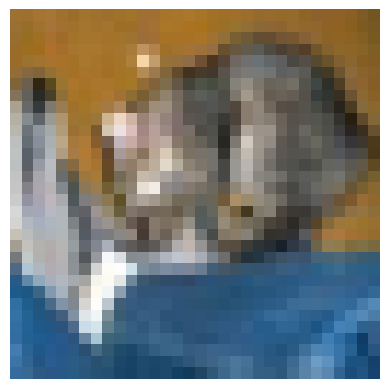

In [ ]:
import matplotlib.pyplot as plt

# test 이미지 하나 선택
idx = 0

x = x_test_cd[idx:idx+1]
t = t_test_cd[idx]

# 예측
scores = network.predict(x)

pred = np.argmax(scores, axis=1)[0]

print("모델 출력:", scores)
print("예측:", "고양이" if pred == 0 else "개")
print("정답:", "고양이" if t == 0 else "개")

# 이미지 표시
img = x_test_cd[idx].transpose(1, 2, 0)

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
def batch_accuracy(network, x, t, batch_size=50):
    accuracy_sum = 0

    for i in range(0, len(x), batch_size):
        x_batch = x[i:i + batch_size]
        t_batch = t[i:i + batch_size]

        y = network.predict(x_batch)

        pred = np.argmax(y, axis=1)

        accuracy_sum += np.sum(pred == t_batch)

    return accuracy_sum / len(x)

In [ ]:
test_acc = batch_accuracy(
    network,
    x_test_cd,
    t_test_cd,
    batch_size=50
)

print(f"최종 test accuracy: {test_acc:.4f}")

최종 test accuracy: 0.5635


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

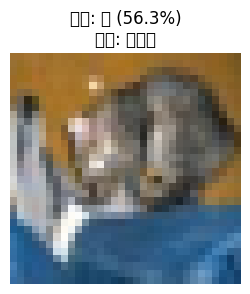

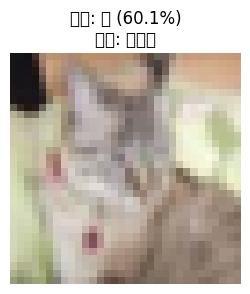

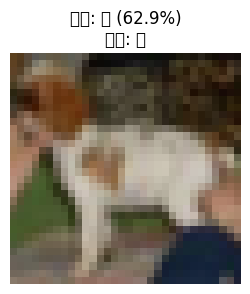

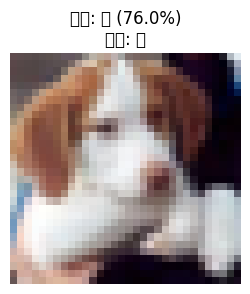

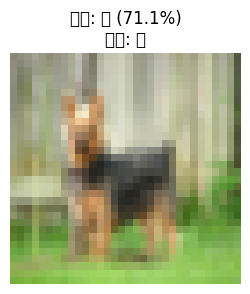

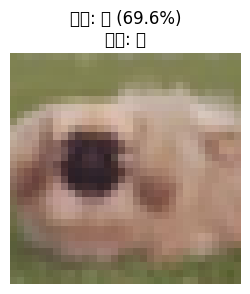

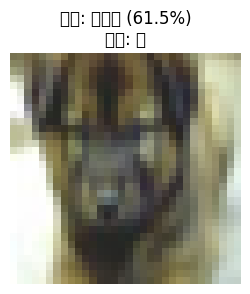

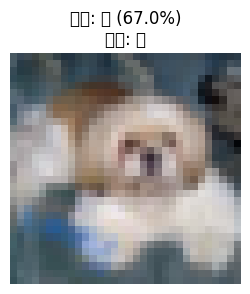

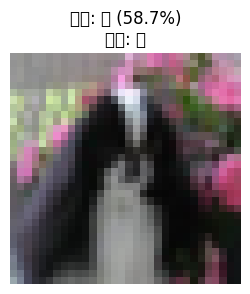

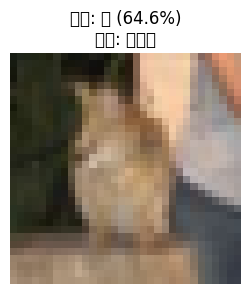

In [ ]:
import matplotlib.pyplot as plt

for idx in range(10):

    x = x_test_cd[idx:idx + 1]
    t = t_test_cd[idx]

    scores = network.predict(x)
    prob = softmax(scores)

    pred = np.argmax(prob, axis=1)[0]

    img = x_test_cd[idx].transpose(1, 2, 0)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")

    pred_name = "고양이" if pred == 0 else "개"
    true_name = "고양이" if t == 0 else "개"

    plt.title(
        f"예측: {pred_name} "
        f"({prob[0, pred] * 100:.1f}%)\n"
        f"정답: {true_name}"
    )

    plt.show()

In [ ]:
!apt-get -qq install fonts-nanum

Selecting previously unselected package fonts-nanum.
(Reading database ... 122797 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

print("폰트:", font_prop.get_name())

폰트: NanumGothic


Text(0.5, 1.0, '예측: 개 (64.6%)\n정답: 고양이')

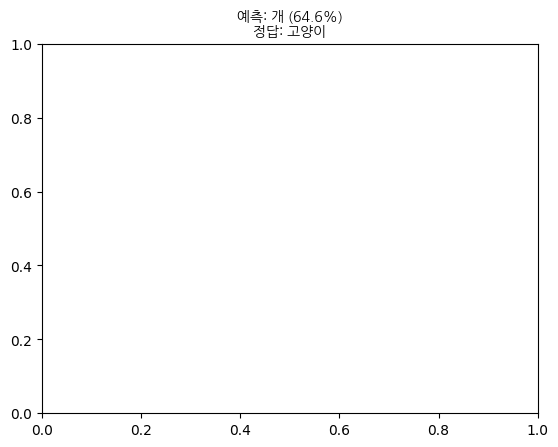

In [ ]:
plt.title(
    f"예측: {pred_name} "
    f"({prob[0, pred] * 100:.1f}%)\n"
    f"정답: {true_name}",
    fontproperties=font_prop
)

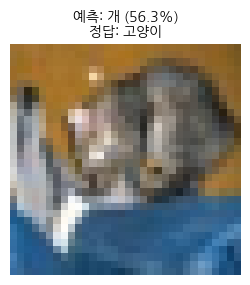

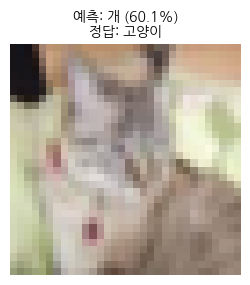

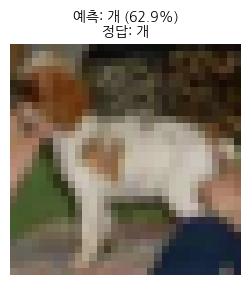

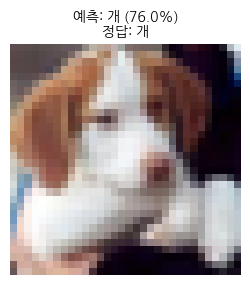

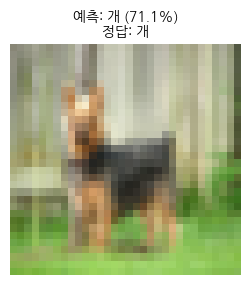

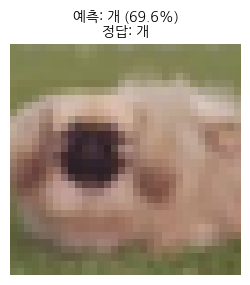

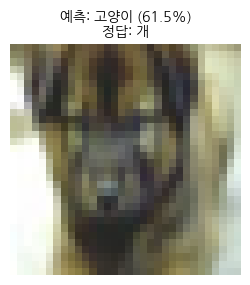

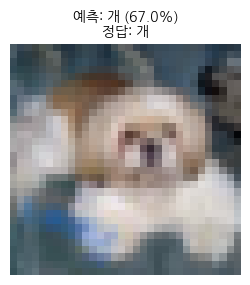

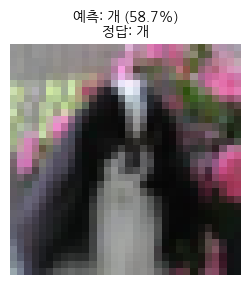

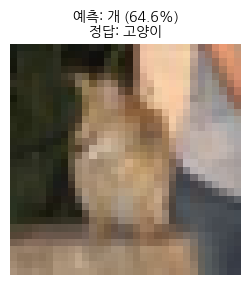

In [ ]:
for idx in range(10):

    x = x_test_cd[idx:idx + 1]
    t = t_test_cd[idx]

    scores = network.predict(x)
    prob = softmax(scores)

    pred = np.argmax(prob, axis=1)[0]

    img = x_test_cd[idx].transpose(1, 2, 0)

    pred_name = "고양이" if pred == 0 else "개"
    true_name = "고양이" if t == 0 else "개"

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"예측: {pred_name} "
        f"({prob[0, pred] * 100:.1f}%)\n"
        f"정답: {true_name}",
        fontproperties=font_prop
    )

    plt.show()

In [ ]:
test_acc = batch_accuracy(
    network,
    x_test_cd,
    t_test_cd,
    batch_size=50
)

print(f"최종 test accuracy: {test_acc:.4f}")
print(f"최종 test accuracy: {test_acc * 100:.2f}%")

최종 test accuracy: 0.5635
최종 test accuracy: 56.35%


In [ ]:
cat_correct = 0
cat_total = 0

dog_correct = 0
dog_total = 0

for i in range(0, len(x_test_cd), 50):

    x_batch = x_test_cd[i:i+50]
    t_batch = t_test_cd[i:i+50]

    scores = network.predict(x_batch)
    pred = np.argmax(scores, axis=1)

    # 고양이
    cat_mask = (t_batch == 0)
    cat_total += np.sum(cat_mask)
    cat_correct += np.sum(
        pred[cat_mask] == t_batch[cat_mask]
    )

    # 개
    dog_mask = (t_batch == 1)
    dog_total += np.sum(dog_mask)
    dog_correct += np.sum(
        pred[dog_mask] == t_batch[dog_mask]
    )

print(f"고양이 정확도: {cat_correct / cat_total:.4f}")
print(f"개 정확도: {dog_correct / dog_total:.4f}")

고양이 정확도: 0.2420
개 정확도: 0.8850


In [ ]:
print("train 고양이:", np.sum(t_small == 0))
print("train 개:", np.sum(t_small == 1))

print("validation 고양이:", np.sum(t_val == 0))
print("validation 개:", np.sum(t_val == 1))

train 고양이: 991
train 개: 1009
validation 고양이: 1003
validation 개: 997


In [ ]:
network2 = CatDogConvNet()
optimizer2 = Adam(lr=0.0001)

train_size = len(x_train_final)
batch_size = 50
epochs = 5

for epoch in range(epochs):

    indices = np.random.permutation(train_size)

    for i in range(0, train_size, batch_size):

        batch_idx = indices[i:i + batch_size]

        x_batch = x_train_final[batch_idx]
        t_batch = t_train_final[batch_idx]

        grads = network2.gradient(
            x_batch,
            t_batch
        )

        optimizer2.update(
            network2.params,
            grads
        )

    train_acc = batch_accuracy(
        network2,
        x_train_final[:1000],
        t_train_final[:1000]
    )

    val_acc = batch_accuracy(
        network2,
        x_val,
        t_val
    )

    print(
        f"epoch {epoch + 1} | "
        f"train acc {train_acc:.4f} | "
        f"val acc {val_acc:.4f}"
    )

epoch 1 | train acc 0.5900 | val acc 0.5955
epoch 2 | train acc 0.6600 | val acc 0.6345
epoch 3 | train acc 0.6930 | val acc 0.6530
epoch 4 | train acc 0.6950 | val acc 0.6650
epoch 5 | train acc 0.7170 | val acc 0.6665


In [ ]:
test_acc = batch_accuracy(
    network2,
    x_test_cd,
    t_test_cd,
    batch_size=50
)

print(f"전체 test 정확도: {test_acc:.4f}")

전체 test 정확도: 0.6820


In [ ]:
cat_correct = 0
cat_total = 0
dog_correct = 0
dog_total = 0

for i in range(0, len(x_test_cd), 50):
    x_batch = x_test_cd[i:i+50]
    t_batch = t_test_cd[i:i+50]

    scores = network2.predict(x_batch)
    pred = np.argmax(scores, axis=1)

    cat_mask = (t_batch == 0)
    dog_mask = (t_batch == 1)

    cat_total += np.sum(cat_mask)
    dog_total += np.sum(dog_mask)

    cat_correct += np.sum(pred[cat_mask] == 0)
    dog_correct += np.sum(pred[dog_mask] == 1)

print(f"고양이 정확도: {cat_correct / cat_total:.4f}")
print(f"개 정확도: {dog_correct / dog_total:.4f}")

고양이 정확도: 0.6140
개 정확도: 0.7500


In [ ]:
for epoch in range(5, 10):

    indices = np.random.permutation(train_size)

    for i in range(0, train_size, batch_size):

        batch_idx = indices[i:i + batch_size]

        x_batch = x_train_final[batch_idx]
        t_batch = t_train_final[batch_idx]

        grads = network2.gradient(
            x_batch,
            t_batch
        )

        optimizer2.update(
            network2.params,
            grads
        )

    train_acc = batch_accuracy(
        network2,
        x_train_final[:1000],
        t_train_final[:1000]
    )

    val_acc = batch_accuracy(
        network2,
        x_val,
        t_val
    )

    print(
        f"epoch {epoch + 1} | "
        f"train acc {train_acc:.4f} | "
        f"val acc {val_acc:.4f}"
    )

epoch 6 | train acc 0.7270 | val acc 0.6905
epoch 7 | train acc 0.7430 | val acc 0.6895
epoch 8 | train acc 0.7360 | val acc 0.6750
epoch 9 | train acc 0.7560 | val acc 0.6895
epoch 10 | train acc 0.7650 | val acc 0.6955


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving images.jpg to images.jpg


In [ ]:
filename = list(uploaded.keys())[0]

print(filename)

images.jpg


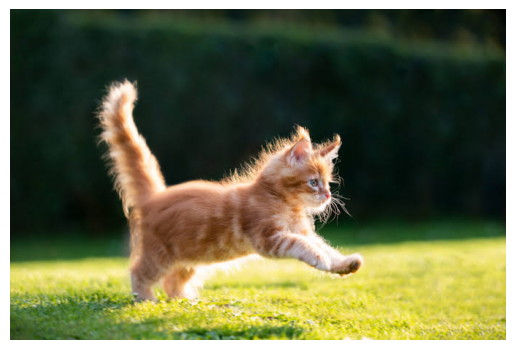

(1, 3, 32, 32)


In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 이미지 열기
img = Image.open(filename).convert("RGB")

# 원본 보여주기
plt.imshow(img)
plt.axis("off")
plt.show()

# CIFAR-10과 같은 32×32로 변경
img_resized = img.resize((32, 32))

# PIL Image → NumPy
x = np.array(img_resized)

# float32 + 0~1 정규화
x = x.astype(np.float32) / 255.0

# (H,W,C) → (C,H,W)
x = x.transpose(2, 0, 1)

# 한 장짜리 batch 만들기
x = x.reshape(1, 3, 32, 32)

print(x.shape)

In [ ]:
scores = network2.predict(x)

prob = softmax(scores)

pred = np.argmax(prob, axis=1)[0]

print(f"고양이 확률: {prob[0, 0] * 100:.2f}%")
print(f"개 확률: {prob[0, 1] * 100:.2f}%")

if pred == 0:
    print("모델의 판단: 고양이")
else:
    print("모델의 판단: 개")

고양이 확률: 38.85%
개 확률: 61.15%
모델의 판단: 개


In [ ]:
from PIL import Image
import numpy as np

def classify_image(img):
    # 1. RGB로 통일
    img = img.convert("RGB")

    # 2. CIFAR-10 크기로 변경
    img = img.resize((32, 32))

    # 3. PIL → NumPy
    x = np.array(img)

    # 4. 0~255 → 0~1
    x = x.astype(np.float32) / 255.0

    # 5. (H,W,C) → (C,H,W)
    x = x.transpose(2, 0, 1)

    # 6. 이미지 한 장짜리 batch
    x = x.reshape(1, 3, 32, 32)

    # 7. 우리가 만든 CNN
    scores = network2.predict(x)

    # 8. 확률
    prob = softmax(scores)

    cat_prob = prob[0, 0]
    dog_prob = prob[0, 1]

    # 9. 최종 판단
    if cat_prob > dog_prob:
        result = "고양이"
    else:
        result = "개"

    return result, cat_prob, dog_prob

In [ ]:
!pip install -q gradio

In [ ]:
import gradio as gr

In [ ]:
def chatbot(image):
    if image is None:
        return "이미지를 올려주세요!"

    result, cat_prob, dog_prob = classify_image(image)

    answer = (
        f"이 이미지는 **{result}**로 판단했습니다.\n\n"
        f"고양이 확률: {cat_prob * 100:.1f}%\n"
        f"개 확률: {dog_prob * 100:.1f}%"
    )

    return answer

In [ ]:
demo = gr.Interface(
    fn=chatbot,

    inputs=gr.Image(
        type="pil",
        label="고양이 또는 개 사진"
    ),

    outputs=gr.Markdown(
        label="AI의 답변"
    ),

    title="🐱🐶 Cat & Dog AI",
    description="직접 구현한 CNN이 고양이와 개를 구분합니다."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c1ae20297fe48aee5d.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
